<a href="https://colab.research.google.com/github/tonyyucrachurata-dev/el-buen-sabor-mvp/blob/main/TALLER_RNA_008.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**---CLASIFICACIÓN BINARIA CON RNA CONVOLUCIONAL---**

IMPORTAMOS BIBLIOTECAS

In [9]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

In [10]:
(ds_train, ds_test),ds_info= tfds.load(
    'cats_vs_dogs',
    split=['train[:80%]','train[80%:]'],
    as_supervised= True,
    with_info= True
)

In [11]:
def preprocess(img, label):
  img= tf.image.resize(img, (128,128))
  img= tf.cast(img, tf.float32)/255.0
  return img, label

In [12]:
ds_train= ds_train.map(preprocess).shuffle(1000).batch(32).prefetch(1)
ds_test= ds_test.map(preprocess).batch(32).prefetch(1)

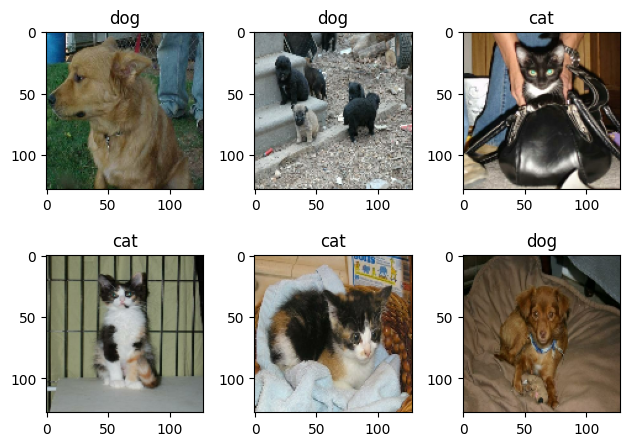

In [15]:
for img, label in ds_train.take(1):
  for i in range(6):
    plt.subplot(2,3, i+1)
    plt.imshow(img[i])
    plt.title('dog' if label[i] else 'cat')
    plt.tight_layout()
plt.show()

In [21]:
model= tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(128,128,3)), #alto, ancho, y cantidad_de_canales_de_color
    tf.keras.layers.Conv2D(16, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [22]:
model.compile(optimizer='adam', loss='binary_crossentropy')
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       802,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 826,529 (3.15 MB)

 Trainable params: 826,529 (3.15 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
model.fit(ds_train, epochs=6, validation_data= ds_test)

Epoch 1/6
582/582 ━━━━━━━━━━━━━━━━━━━━ 36s 50ms/step - loss: 0.6306 - val_loss: 0.5350
Epoch 2/6
582/582 ━━━━━━━━━━━━━━━━━━━━ 30s 50ms/step - loss: 0.5091 - val_loss: 0.4629
Epoch 3/6
582/582 ━━━━━━━━━━━━━━━━━━━━ 27s 45ms/step - loss: 0.4406 - val_loss: 0.4317
Epoch 4/6
582/582 ━━━━━━━━━━━━━━━━━━━━ 27s 44ms/step - loss: 0.3939 - val_loss: 0.4103
Epoch 5/6
582/582 ━━━━━━━━━━━━━━━━━━━━ 27s 44ms/step - loss: 0.3505 - val_loss: 0.3902
Epoch 6/6
582/582 ━━━━━━━━━━━━━━━━━━━━ 41s 44ms/step - loss: 0.3127 - val_loss: 0.4235


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 597ms/step


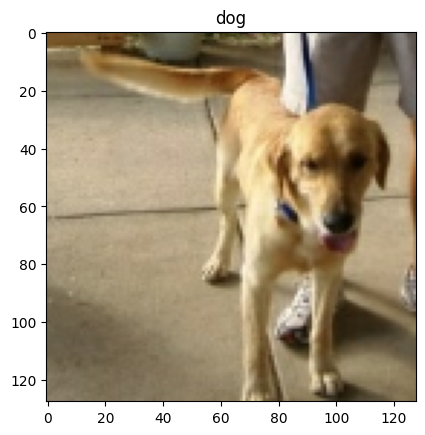

In [24]:
for img, label in ds_test.take(1):
  pred= model.predict(img)
  plt.imshow(img[0])
  plt.title('dog' if pred[0] > 0.5 else 'cat')